# Исследовательский анализ рынка общественного питания Москвы для Shut Up and Take My Money.

- Автор: Сереженко Елена

### Цели и задачи проекта

Провести исследовательский анализ заведений общественного питания Москвы с целью поиска подходящего места для потенциального открытия на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года.

**Задачи:**
1. Загрузка данных и знакомство с ними. Общая информация, особенность данных.
2. Проведение предобработки данных. При необходимости преобразование типов данных, поиск и замена `NaN` и дубликатов.
3. Проведение исследовательского анализа данных:
 - анализ категорий точек общественного питания в Москве (какие категории наиболее распространены);
 - анализ мест расположения точек общественного питания в Москве (распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы);
 - анализ сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения;
 - исследование количества посадочных мест в заведениях (для каждой категории заведения наиболее типичного для него количество посадочных мест);
 - рейтинг заведений и распределение средних рейтингов по категориям заведений;
 - корреляции рейтинга заведений с другими данными (категория, положение, статус сетевого заведения, количество мест, ценовая категория и признак - является ли заведения круглосуточным);
 - ТОП-15 популярных сетей в Москве;
 - анализ цен в Центральном административном округе и других.
4. Формулирование итогового вывода и рекомендаций


### Описание данных

Файл `/datasets/rest_info.csv` содержит информацию о заведениях общественного питания:
- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведение, например Центральный административный округ;
- `category` — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
  - 0 — заведение не является сетевым;
  - 1 — заведение является сетевым.
- `seats` — количество посадочных мест.

Файл `/datasets/rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- `price` — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона, например:
  - «Средний счёт: 1000–1500 ₽»;
  - «Цена чашки капучино: 130–220 ₽»;
  - «Цена бокала пива: 400–600 ₽».
  - и так далее;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта

* [1. Загрузка данных и знакомство с ними.](#1.-Загрузка-данных-и-знакомство-с-ними)
* [2. Предобработка данных.](#2.-Предобработка-данных)
* [3. Исследовательский анализ данных.](#3.-Исследовательский-анализ-данных)
* [4. Итоговый вывод и рекомендации.](#4.-Итоговый-вывод-и-рекомендации)

## 1. Загрузка данных и знакомство с ними

Загрузка необходимых библиотек и данных о заведениях общественного питания Москвы.
Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Загружаем библиотеку для расчета коэффициента корреляции phi_k
from phik import phik_matrix

In [3]:
# Выгружаем данные в переменные df_info и df_price
df_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
df_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Предпросмотр данных датасета `/datasets/rest_info.csv`.

In [4]:
# Выводим первые строки датасета на экран
df_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
# Выводим информацию о датасета
df_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


Датасет `df_info` содержит 9 колонок и 8406 строк.

После первичного анализа можно сделать следующие выводы:
- `id`, `name`, `adress`, `hours`, `category`, `district` - строковые типы данных, к ним корректно применен тип `object`;
- `rating` - тип данных `float64`, можно уменьшить разрядность;
- `seats` - тип данных `float64`, необходимо преобразовать в `integer`, уменьшить разрядность;
- `chain` - тип данных `int64`, но содержит только 1 или 0, данные можно оптимизировать и уменьшить разрядность;
- `hours` и `seats` содержат пропуски.

Предпросмотр данных датасета `/datasets/rest_price.csv`.

In [6]:
# Выводим первые строки датасета на экран
df_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [7]:
# Выводим информацию о датасете
df_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


Датасет `df_price` содержит 5 колонок и 4058 строк.

После первичного анализа можно сделать следующие выводы:
- типы данных соответствуют содержимому;
- числовые типы данных можно понизить в разрядности;
- пропуски содержатся во всех столбцах, кроме `id`. Наибольшее количество пропусков в `middle_coffee_cup`.

### Промежуточный вывод

Знакоство с данными показало:
- все названия столбцов указаны верно, не нуждаются в изменениях;
- данные в столбцах соответсвуют названиям столбцов;
- требуется произвести преобразования типов данных(понижение разрядности);
- датасеты содержат пропуски.

### Подготовка единого датасета

In [8]:
# Присоединим к датасету df_info данные о стоимости df_price
merged_df = df_info.merge(df_price, on='id', how='left')

In [9]:
# Выводим первые строки единого датасета на экран
merged_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [10]:
# Выводим информацию о датасете
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


In [11]:
# Cоздаём копию единого датасета до преобразования
copy_merged_df = merged_df.copy()

## 2. Предобработка данных

**Проведём оптимизацию представленных данных в едином датасете.**

In [12]:
# Столбец 'chain' к int с пониженной разрядностью
merged_df['chain'] = pd.to_numeric(merged_df['chain'], downcast='integer')

In [13]:
# Столбец 'seats' к int с сохранением NaN
merged_df['seats'] = merged_df['seats'].astype(pd.Int16Dtype())

In [14]:
# Для столбцов 'rating', 'middle_avg_bill', 'middle_coffee_cup' понижение разрядности
for column in ['rating','middle_avg_bill','middle_coffee_cup']:
    merged_df[column] = pd.to_numeric(merged_df[column], downcast='float')

In [15]:
# Проверим типы данных в датасете merged_df после преобразований
merged_df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                  Int16
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

In [16]:
# Проверим корректность написания значений в данных, выедим уникальные значения
for column in ['category', 'district', 'price']:
    print(f'Уникальные значения в столбце {column}:')
    print(merged_df[column].sort_values().unique())
    print()

Уникальные значения в столбце category:
['бар,паб' 'булочная' 'быстрое питание' 'кафе' 'кофейня' 'пиццерия'
 'ресторан' 'столовая']

Уникальные значения в столбце district:
['Восточный административный округ' 'Западный административный округ'
 'Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Центральный административный округ'
 'Юго-Восточный административный округ'
 'Юго-Западный административный округ' 'Южный административный округ']

Уникальные значения в столбце price:
['высокие' 'выше среднего' 'низкие' 'средние' nan]



Ошибок нет в обозначениях категорий, округов и классификаций цен.

In [17]:
# Приведём все названия и адреса к единому стилю написания, убирём лишние пробелы
merged_df['name'] = merged_df['name'].str.capitalize().str.strip().str.replace(r' +', ' ', regex=True)
merged_df['address'] = merged_df['address'].str.lower().str.strip().str.replace(r' +', ' ', regex=True)

In [18]:
# Выведим первые строки датасета для проверки после изменений
merged_df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,Wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN


Все столбцы оптимизированы, приведены в необходимые типы данных и готовы для дальнейшей работы. 

**Проверим наличие пропусков в датасете `merged_df`.** 

При первичном анализе обнаружили пропуски в столбцах `hours`, `seats`, `price`, `avg_bill`, `middle_avg_bill`, `middle_coffee_cup`.

Найдём абсолютное и относительное количества пропусков.

In [19]:
# Применяем метод isna() к датаcету merged_df
merged_df.isna().sum().sort_values()

id                      0
name                    0
category                0
address                 0
district                0
rating                  0
chain                   0
hours                 536
seats                3611
avg_bill             4590
price                5091
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [20]:
# Посчитаем долю строк с пропусками
merged_df.isna().mean().sort_values()

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
rating               0.000000
chain                0.000000
hours                0.063764
seats                0.429574
avg_bill             0.546039
price                0.605639
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В столбцах `hours`, `seats`, `avg_bill`, `price`, `middle_avg_bill`, `middle_coffee_cup` датафрейма `merged_df` пропущено 536, 3611, 4590, 5091, 5257, 7871 строк соответственно. Разбег пропуска в процентах составляет от 6,3% до 93.6% от общего количества.

Число пропусков достаточно велико.

Можно предположить, что пропуски в столбцах `seats` и `hours` появились из-за ошибки сбора данных с серверов либо изначального отсутствия данных.

Большое число пропусков в столбцах `avg_bill`, `price`, `middle_avg_bill`, `middle_coffee_cup` вышло из-за объединения датасетов. Число строк датасета `df_info` больше числа строк `price_df`.

От столбца `avg_bill` зависят другие столбцы. Предположим, что пропуски в `avg_bill` возникли, т.к. эти данные собраны с источников, в которых могут быть не указаны ценовые диапозоны для заведений либо это новые заведения без данных.

Для столбцов `middle_avg_bill`, `middle_coffee_cup` могут отсутствовать значения в связи с отсутсвием данных по категории и общих данных в столбце avg_bill, что было отмечено ранее.

<b>Вывод:</b> удаление строк либо замена значений в пропусках в данном случае сильно исказит дальнейший анализ.

**Проверим данные на наличие явных и неявных дубликатов.**

In [21]:
# Посчитаем общее количество строк до обработки дубликатов
total_rows = len(merged_df)
print(f'Общее количество строк: {total_rows}')

Общее количество строк: 8406


In [22]:
# Проверим явные дубликаты в датасете merged_df
merged_df.duplicated().sum()

np.int64(0)

In [23]:
# Проверим неявные дубликаты по id заведения
merged_df.duplicated(subset='id').sum()

np.int64(0)

In [24]:
# Проверим неявные дубликаты по названию и адресу
merged_df.duplicated(subset=['name', 'address']).sum()

np.int64(4)

In [25]:
# Выведем данные дубликаты для уточнения
merged_df[merged_df.duplicated(subset=['name', 'address'], keep=False)]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
189,072032ce16dc47bfbc63b672c75bd371,Кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 09:00–23:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
215,897ddbc6746c4388b19dc8a9fcdbb488,Кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,<NA>,NaN,NaN,NaN,NaN
1430,62608690e9cc464fbcd980cfd552e334,More poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"ежедневно, 09:00–21:00",4.2,0,188,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,More poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188,NaN,NaN,NaN,NaN
2211,c6ef39ae8a8c483d8f9a6531bc386a2c,Раковарня клешни и хвосты,ресторан,"москва, проспект мира, 118",Северо-Восточный административный округ,"ежедневно, 12:00–00:00",4.4,0,150,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,Раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150,NaN,NaN,NaN,NaN
3091,3c2a73ea79a04be48858fab3685f2f37,Хлеб да выпечка,булочная,"москва, ярцевская улица, 19",Западный административный округ,"ежедневно, 09:00–22:00",4.1,1,276,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,Хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276,NaN,NaN,NaN,NaN


Видим явные дубликаты. Где-то указаны разные категории, где-то разное время работы. В данном случае их можно удалить.

In [26]:
# Удалим дубликаты
merged_df = merged_df.drop_duplicates(subset=['name', 'address'], keep='last') 

In [27]:
# Проверим количество строк после удаления дубликатов
total_rows = len(merged_df)
print(f'Общее количество строк после удаления дубликатов: {total_rows}')

Общее количество строк после удаления дубликатов: 8402


**Добавим дополнительный столбец `is_24_7`.**

Он обозначает, что заведение работает круглосуточно без выходных.

In [28]:
# Расширим пулл возможных вариантов
hours_is_24_7 = [
    'ежедневно, круглосуточно',
    'круглосуточно',
    '24/7',
    '24х7',
    '24*7',
    '24часа',
    '24 часа',
    '00:00-24:00',
    '0:00-24:00',
    '00:00-00:00',
    'круглосуток',
    '24 часа в сутки'
]
# Добавляем новый столбец
merged_df['is_24_7'] = merged_df['hours'].apply(
    lambda x: 1 if isinstance(x, str) and any(pattern in x for pattern in hours_is_24_7) else 0
)
merged_df

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,Wowфли,кафе,"москва, улица дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,<NA>,NaN,NaN,NaN,NaN,0
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"москва, улица дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"москва, клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45,средние,Средний счёт:от 1000 ₽,1000.0,NaN,0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,<NA>,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0,0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль марко,пиццерия,"москва, правобережная улица, 1б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148,средние,Средний счёт:400–600 ₽,500.0,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8401,0342ad1a45ed41ba89dcba246a8267e5,Суши мания,кафе,"москва, профсоюзная улица, 56",Юго-Западный административный округ,"ежедневно, 09:00–02:00",4.4,0,86,NaN,NaN,NaN,NaN,0
8402,ee6bb7c3650e47bd8186fca08eda1091,Миславнес,кафе,"москва, пролетарский проспект, 19, корп. 1",Южный административный округ,"ежедневно, 08:00–22:00",4.8,0,150,NaN,NaN,NaN,NaN,0
8403,62e8c64d4c89467aba608e39ef87616b,Самовар,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",3.9,0,150,NaN,Средний счёт:от 150 ₽,150.0,NaN,1
8404,06a0db5ecd4842d48cd6350aa923e297,Чайхана sabr,кафе,"москва, люблинская улица, 112а, стр. 1",Юго-Восточный административный округ,"ежедневно, круглосуточно",4.2,1,150,NaN,NaN,NaN,NaN,1


In [29]:
# Выведем количество заведений, работающих по графику(0) и 24/7(1)
merged_df['is_24_7'].value_counts()

is_24_7
0    7630
1     772
Name: count, dtype: int64

**Предобработка данных завершена.**

### Промежуточный вывод

После обработки в датасете осталось 8402 строки и 14 столбцов.
Данные содержат пропуски в 6 столбцах:
- `hours` - 6.38%;
- `seats` - 42.96%;
- `price` - 60.56%;
- `avg_bill` - 54.60%;
- `middle_avg_bill` - 62.54%;
- `middle_coffee_cup` - 93.64%.
Удаление строк либо замена значений в пропусках в данном случае сильно исказит дальнейший анализ. Оставляем без изменений.
Было удалено четыре неявных дубликата.
Добавлен новый столбец `is_24_7`, который обозначает работу заведения круглосуточно безвыходных. Необходим для дальнейших вычислений.

## 3. Исследовательский анализ данных

In [30]:
# Выведем основные метрики
merged_df[['rating', 'seats', 'middle_avg_bill', 'middle_coffee_cup']].describe()

,rating,seats,middle_avg_bill,middle_coffee_cup
count,8402.000000,4792.0,3149.000000,535.000000
mean,4.230017,108.361436,958.053650,174.721497
std,0.470318,122.84113,1009.734436,88.951088
min,1.000000,0.0,0.000000,60.000000
25%,4.100000,40.0,375.000000,124.500000
50%,4.300000,75.0,750.000000,169.000000
75%,4.400000,140.0,1250.000000,225.000000
max,5.000000,1288.0,35000.000000,1568.000000


В столбце `rating` среднее значение(4.23) и медиана(4.3). Min=1.0 и Max=5.0, что соответсвует действительным значениям. 

В столбце `seats` среднее значение(108.4) и медиана(75) сильно разнятся. Видим высокое стандартное отклонение(122.8). Эти факторы могут говорить о выбросах в значениях. Посмотрим на Max(1288 мест), такое значение может подтвердить данный вывод.

В столбце `middle_avg_bill` среднее значение(958) и медиана(750) тоже сильно отличаются, высокое стандартное отклонение - 1009. Высокое максимальное значение(35 000) и минимальное значение(0).

В столбце `middle_coffee_cup` среднее значение(174.7) сравнимо с медианой(169). Min(60) и Max(1568) значения за кружку кофе.

### Задача 1

Категории заведений, количество объектов общественного питания по каждой категории.

In [31]:
# Выведем категории заведений
merged_df['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [32]:
# Сгруппируем по категориям(понадобится для построения диаграммы)
counts_cat = merged_df.groupby('category').size().sort_values(ascending=False)
print("Количество заведений по категориям:")
print(counts_cat)

Количество заведений по категориям:
category
кафе               2377
ресторан           2041
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            255
dtype: int64


In [33]:
# Посмотрим в относительных значениях
merged_df['category'].value_counts(normalize=True)

category
кафе               0.282909
ресторан           0.242918
кофейня            0.168174
бар,паб            0.091050
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030350
Name: proportion, dtype: float64

Для визуалиции построим столбчатую диаграмму для категорий заведений по количеству.

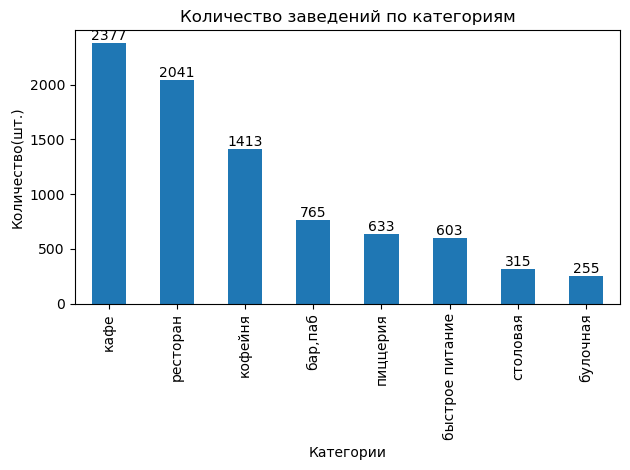

In [34]:
# Построим столбчатую диаграмму
counts_cat.plot(kind='bar')
plt.title('Количество заведений по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество(шт.)')

# Добавим подписи на столбцы
for i, v in enumerate(counts_cat):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Выводы распределения заведений по категориям.**

В базе 8402 заведения.
Большая часть в категориях:
- кафе - 2377 шт., доля от общего 28.29%;
- ресторан - 2041 шт., доля от общего 24.29%;
- кофейня - 1413 шт., доля от общего 16.81%.

Аутсайдерами стали булочные(255 штук) и столовых(315 штук).

### Задача 2

Административные районы Москвы, распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы.

Продублируем список Административных районов, добавим количество заведений на каждый.

In [35]:
# Сгруппируем по районам(понадобится для построения диаграммы)
counts_district=merged_df.groupby('district').size().sort_values(ascending=False)
print(counts_district)

district
Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
dtype: int64


In [36]:
# Посмотрим в относительных значениях
merged_df['district'].value_counts(normalize=True)

district
Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: proportion, dtype: float64

In [37]:
# Сократим названия Административных районов для удобства
district_shot = {
    'Центральный административный округ': 'ЦАО',
    'Северный административный округ': 'САО',
    'Южный административный округ': 'ЮАО',
    'Северо-Восточный административный округ': 'СВАО',
    'Западный административный округ': 'ЗАО',
    'Восточный административный округ': 'ВАО',
    'Юго-Восточный административный округ': 'ЮВАО',
    'Юго-Западный административный округ': 'ЮЗАО',
    'Северо-Западный административный округ': 'СЗАО'
}

# Копия названий
district_short_df = counts_district.rename(index=district_shot)

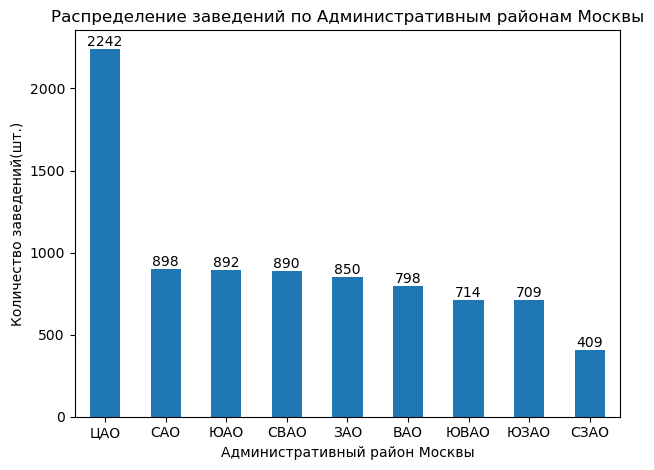

In [38]:
# Строим столбчатую диаграмму(сокращенные названия)
district_short_df.plot(kind='bar')
plt.title('Распределение заведений по Административным районам Москвы')
plt.xlabel('Административный район Москвы')
plt.ylabel('Количество заведений(шт.)')
plt.xticks(rotation=360)

# Добавим подписи на столбцы
for i, v in enumerate(district_short_df):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Были сокращены названия Административных районов Москвы для удобства изображения:
- ЦАО - Центральный административный округ;
- САО - Северный административный округ;
- ЮАО - Южный административный округ;
- СВАО - Северо-Восточный административный округ;
- ЗАО - Западный административный округ;
- ВАО - Восточный административный округ;
- ЮВАО- Юго-Восточный административный округ;
- ЮЗАО- Юго-Западный административный округ;
- СЗАО - Северо-Западный административный округ.

Больше всего заведений сконцентрировано в Центральном административном округе(ЦАО) - 2242 шт., 26.68% от общего в Москве.
Меньше всего в Северо-Западном административном округе(СЗАО) - 409 шт..
В остальных районах варьируется в диапозоне 709-898 шт..

**Уделим внимание Центральному административному округу(ЦАО).**

In [39]:
# Выделим Центральный округ(ЦАО) и сгруппируем по категориям
tsao = merged_df[merged_df['district'] == 'Центральный административный округ']
tsao_merged_df = tsao.groupby('category').size().sort_values(ascending=False)
print(tsao_merged_df)

category
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
dtype: int64


In [40]:
# Посмотрим в относительных значениях
ratio_tsao = tsao['category'].value_counts(normalize=True)
print(ratio_tsao)

category
ресторан           0.298840
кафе               0.206958
кофейня            0.190901
бар,паб            0.162355
пиццерия           0.050401
быстрое питание    0.038805
столовая           0.029438
булочная           0.022302
Name: proportion, dtype: float64


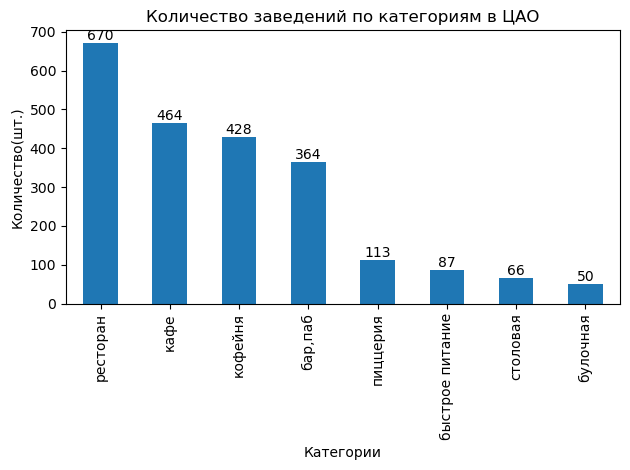

In [41]:
# Строим столбчатую диаграмму
tsao_merged_df.plot(kind='bar')

plt.title('Количество заведений по категориям в ЦАО')
plt.xlabel('Категории')
plt.ylabel('Количество(шт.)')

# Добавим подписи на столбцы
for i, v in enumerate(tsao_merged_df):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

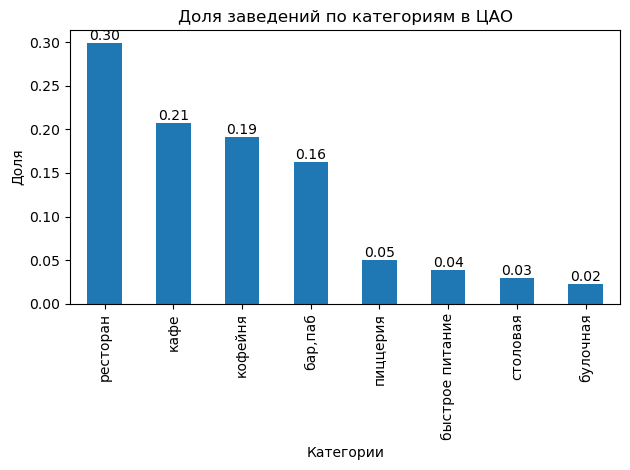

In [42]:
# Строим столбчатую диаграмму
ratio_tsao.plot(kind='bar')

plt.title('Доля заведений по категориям в ЦАО')
plt.xlabel('Категории')
plt.ylabel('Доля')

# Добавим подписи на столбцы
for i, v in enumerate(ratio_tsao):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

В Центральном административном округе 2242 заведения.

Большая часть в категориях:
- ресторан - 670 шт., доля от общего 29.88%;
- кафе - 464 шт., доля от общего 20.7%;
- кофейня - 428 шт., доля от общего 19.09%.

В конце рейтинга оказались булочная(50 шт.) и столовая(66 шт.).

### Задача 3

Соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Выделить категории заведений, которые чаще являются сетевыми.

In [43]:
# Создадим функцию для разделения заведений по типу сети
def chain_name(chain):
    if chain == 0:
        return 'несетевое'
    else: 
        return 'сетевое'

In [44]:
# Разделим заведения на основе данных - сетевое/несетевое
merged_df['chain_names'] = merged_df['chain'].apply(chain_name)
chain_names_df = merged_df['chain_names'].value_counts()
print(chain_names_df)

chain_names
несетевое    5198
сетевое      3204
Name: count, dtype: int64


In [45]:
# Посмотрим в относительных значениях
merged_df['chain_names'].value_counts(normalize=True)

chain_names
несетевое    0.618662
сетевое      0.381338
Name: proportion, dtype: float64

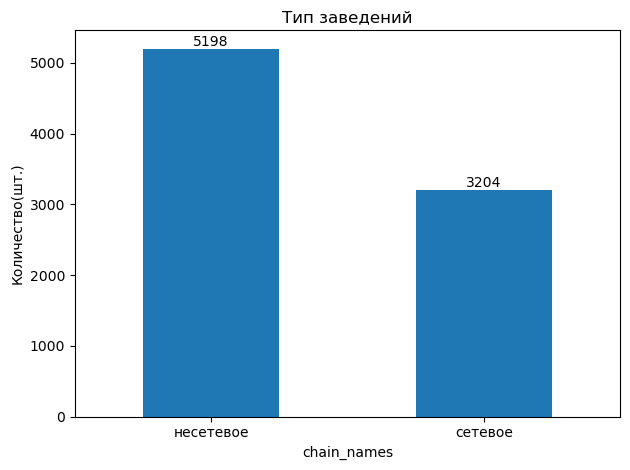

In [46]:
# Строим столбчатую диаграмму
chain_names_df.plot(kind='bar')

plt.title('Тип заведений')
plt.ylabel('Количество(шт.)')
plt.xticks(rotation=360)

# Добавим подписи на столбцы
for i, v in enumerate(chain_names_df):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Исходя из полученных данных в Москве из 8402 заведений общественного питания несетевых - 5198 шт. или 61.87%, сетевых - 3204 шт. или 38.13%, следовательно несетевые заведения значительно преобладают.

Расмотрим эти же данные по категориям заведений.

In [47]:
# Разделим заведения на основе категорий и данных - сетевое/несетевое
cat_chain_names = merged_df.groupby('category')['chain_names'].value_counts()
print(cat_chain_names)

category         chain_names
бар,паб          несетевое       596
                 сетевое         169
булочная         сетевое         156
                 несетевое        99
быстрое питание  несетевое       371
                 сетевое         232
кафе             несетевое      1598
                 сетевое         779
кофейня          сетевое         720
                 несетевое       693
пиццерия         сетевое         330
                 несетевое       303
ресторан         несетевое      1311
                 сетевое         730
столовая         несетевое       227
                 сетевое          88
Name: count, dtype: int64


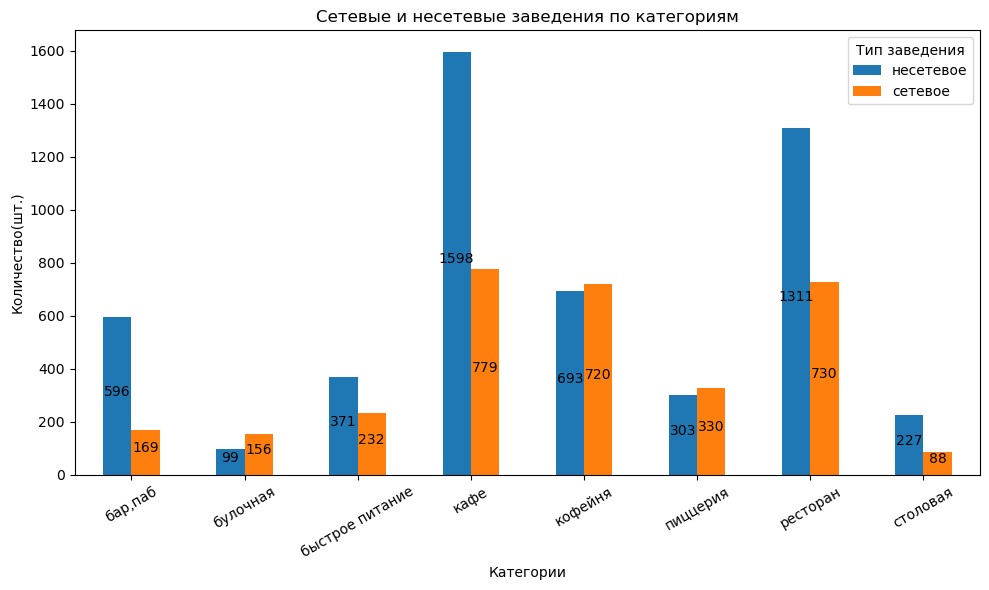

In [48]:
# Строим столбчатую диаграмму 
cross_cat_chain_names = pd.crosstab(merged_df['category'], merged_df['chain_names'])

cross = cross_cat_chain_names.plot(kind='bar', figsize=(10, 6))
    
plt.title('Сетевые и несетевые заведения по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество(шт.)')
plt.legend(title='Тип заведения')
plt.xticks(rotation=30)


# Подписи внутри столбцов
for container in cross.containers:
    cross.bar_label(container, label_type='center', padding=3)

plt.tight_layout()
plt.show()

Выделим категории заведений, которые чаще являются сетевыми.

In [49]:
# Выделим по категориям все сетевые заведения
cat_chain = merged_df[merged_df['chain_names'] == 'сетевое']
cat_chain_true = cat_chain.groupby('category').size().sort_values(ascending=False)
print(cat_chain_true)

category
кафе               779
ресторан           730
кофейня            720
пиццерия           330
быстрое питание    232
бар,паб            169
булочная           156
столовая            88
dtype: int64


In [50]:
# Посмотрим в относительных значениях
cat_chain['category'].value_counts(normalize=True)

category
кафе               0.243134
ресторан           0.227840
кофейня            0.224719
пиццерия           0.102996
быстрое питание    0.072409
бар,паб            0.052747
булочная           0.048689
столовая           0.027466
Name: proportion, dtype: float64

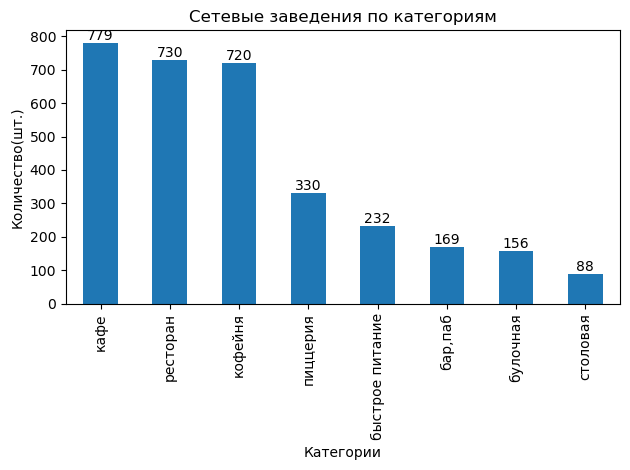

In [51]:
# Строим столбчатую диаграмму
cat_chain_true.plot(kind='bar')

plt.title('Сетевые заведения по категориям')
plt.xlabel('Категории')
plt.ylabel('Количество(шт.)')
plt.xticks(rotation=90)

# Добавим подписи на столбцы
for i, v in enumerate(cat_chain_true):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Большая часть заведений в Москве не являются сетевыми(5198 шт. или 61.87%).

Остальная часть приходится на сетевые заведения. ТОП-3 в данном разрезе будут:
- кафе - 779 шт.;
- ресторан - 730 шт.;
- кофейня -720 шт..

Меньше всего сетевых представлено в категории столовых(88 шт.).

### Задача 4

Количество посадочных мест в заведениях. Аномальные значения. Для каждой категории заведений наиболее типичное для него количество посадочных мест.

In [52]:
# Выведем повторно и отдельно статистические показатели столбца `seats`
merged_df['seats'].describe()

count        4792.0
mean     108.361436
std       122.84113
min             0.0
25%            40.0
50%            75.0
75%           140.0
max          1288.0
Name: seats, dtype: Float64

В столбце `seats` среднее значение(108.4) и медиана(75) сильно разнятся. Видим высокое стандартное отклонение(122.84). Эти факторы могут говорить о выбросах в значениях. Посмотрим на Max(1288 мест), такое значение может подтвердить данный вывод. Для проверки построим гистограмму.

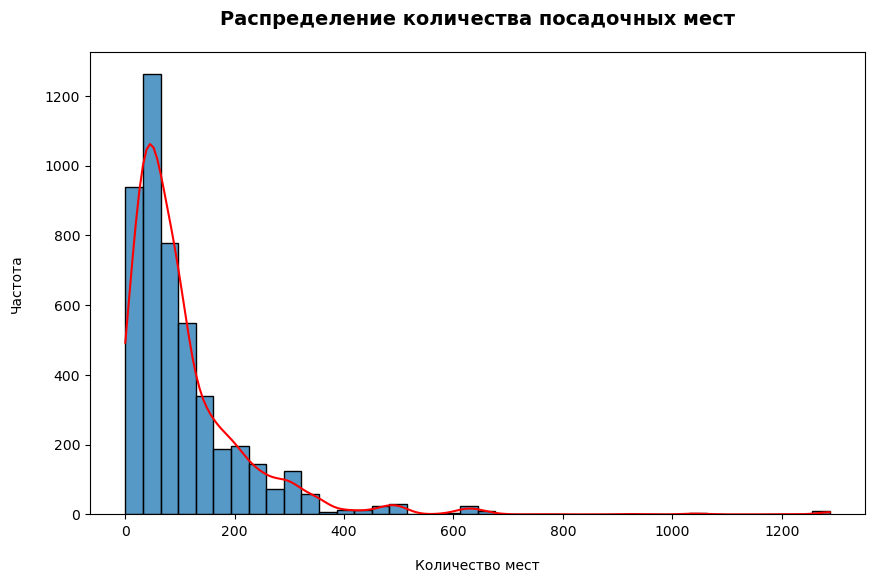

In [53]:
# Строим гистограмму, чтобы увидеть распределение посадочных мест
plt.figure(figsize=(10, 6))
hist_seats = sns.histplot(
    merged_df['seats'],
    bins=40,
    kde=True,
    alpha=0.75,
    edgecolor='black')


plt.ylabel('Частота', labelpad=15)
plt.title('Распределение количества посадочных мест', 
        fontsize=14,  
        fontweight='bold',
        pad=20)
hist_seats.lines[0].set_color('red')
plt.xlabel('Количество мест', labelpad=15)
 
plt.show()

Наблюдаем правостороннюю асимметрию.

Построим boxplot.

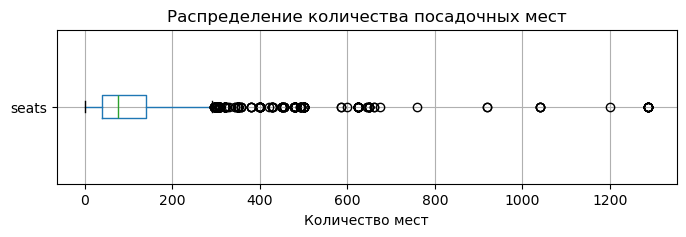

In [54]:
# Создаём ящик с усами для посадочных мест
plt.figure(figsize=(8, 2))
merged_df.boxplot(column='seats', vert=False)

plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')

plt.show()

Основная часть посадочных мест находится в диапазоне от 40(Q1) до 140(Q3).

В данных присутствуют множество выбросов, которые поднимают среднее значение вверх. Однако Min(0) и Max(1288) значения могут быть. Заведение, к примеру, без посадочных мест либо банкетный зал с большой посадкой.

In [55]:
# Посчитаем медиану по посадке для заведений на основе категорий
cat_seats_med = merged_df.groupby('category')['seats'].median().sort_values(ascending=False)
print(cat_seats_med)

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: Float64


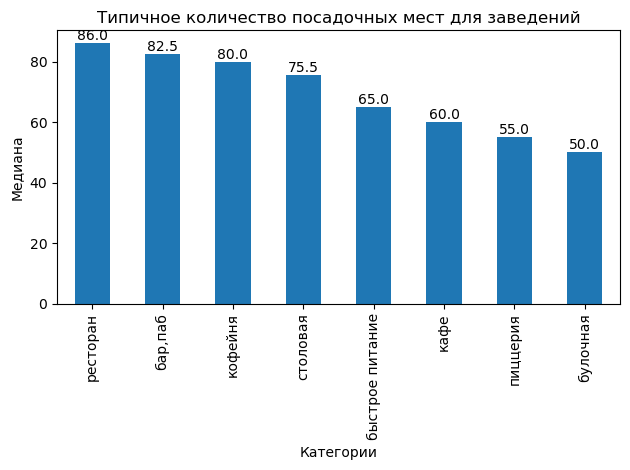

In [56]:
# Строим столбчатую диаграмму
cat_seats_med.plot(kind='bar')

plt.title('Типичное количество посадочных мест для заведений')
plt.xlabel('Категории')
plt.ylabel('Медиана')
plt.xticks(rotation=90)

# Добавим подписи на столбцы
for i, v in enumerate(cat_seats_med):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

Больше всего посадочных мест - в ресторанах, самое маленькое - для булочных, что вполне соответсвует действительности.

### Задача 5

Рейтинг заведений. Визуализация распределений средних рейтингов по категориям заведений.

In [57]:
# Выведем повторно и отдельно статистические показатели столбца `rating`
merged_df['rating'].describe()

count    8402.000000
mean        4.230017
std         0.470318
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

В столбце `rating` среднее значение(4.23) и медиана(4.3). Min=1.0 и Max=5.0, что соответсвует действительным значениям. Стандартное отклонение(0.47) — небольшой разброc, можно сказать, что большинство оценок сосредоточено в узком диапазоне.

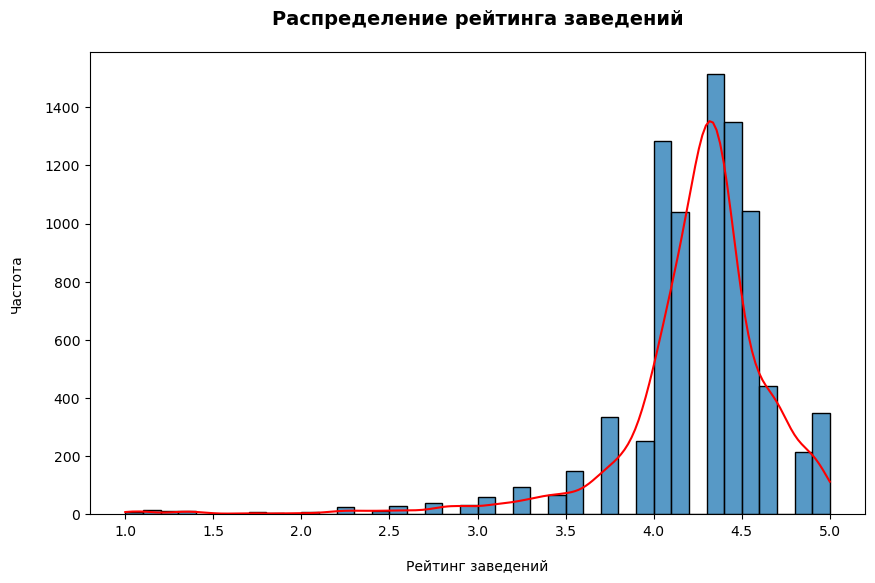

In [58]:
# Строим гистограмму, чтобы увидеть распределение рейтингов заведений
plt.figure(figsize=(10, 6))
hist_rating = sns.histplot(
    merged_df['rating'],
    bins=40,
    kde=True,
    alpha=0.75,
    edgecolor='black')


plt.ylabel('Частота', labelpad=15)
plt.title('Распределение рейтинга заведений', 
        fontsize=14,  
        fontweight='bold',
        pad=20)
hist_rating.lines[0].set_color('red')
plt.xlabel('Рейтинг заведений', labelpad=15)
 
plt.show()

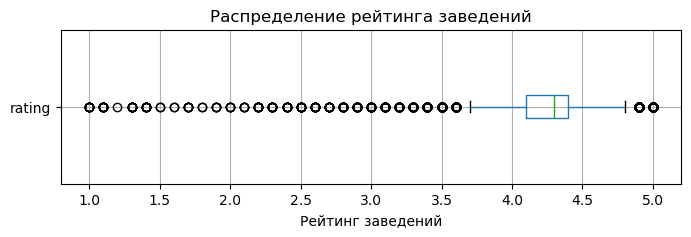

In [59]:
# Создаём ящик с усами для рейтинга заведений
plt.figure(figsize=(8, 2))
merged_df.boxplot(column='rating', vert=False)

plt.title('Распределение рейтинга заведений')
plt.xlabel('Рейтинг заведений')

plt.show()

Распределение рейтинга с левым хвостом.
Основная часть находится в диапазоне от 4.1(Q1) до 4.4(Q3).
Низкий и высокий рейтинги можно не относить к выбросам.

In [60]:
# Посчитаем средний рейтинг для каждой категории
cat_rating_mean = merged_df.groupby('category')['rating'].mean().sort_values(ascending=False)
print(cat_rating_mean)

category
бар,паб            4.387712
пиццерия           4.301264
ресторан           4.290348
кофейня            4.277282
булочная           4.269020
столовая           4.211429
кафе               4.124274
быстрое питание    4.050249
Name: rating, dtype: float32


На это раз построим горизонтальную столбчатую диаграмму, так как значения находятся близко друг к другу.

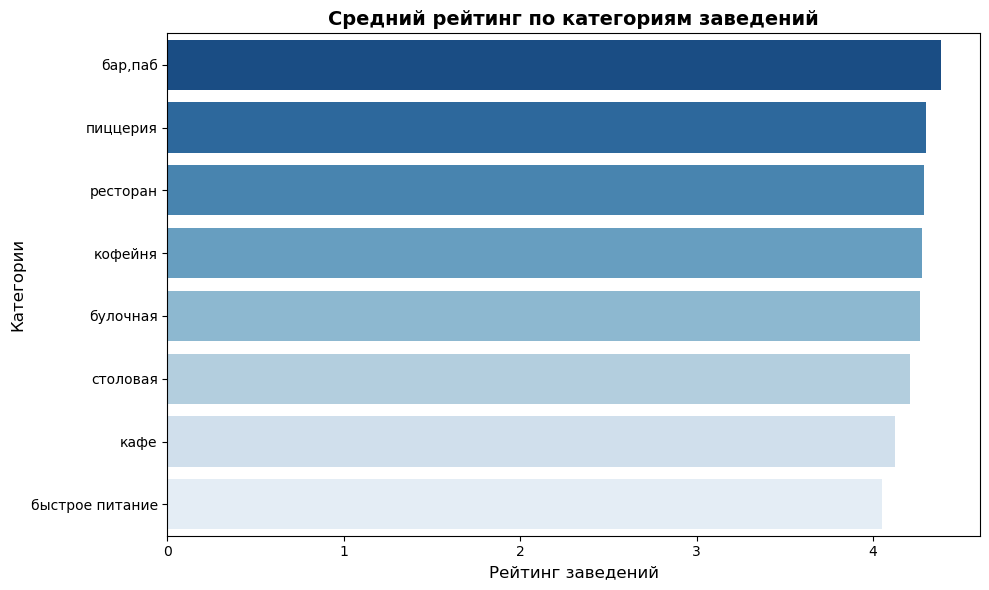

In [61]:
# Создаём график
plt.figure(figsize=(10, 6))
sns.barplot(x=cat_rating_mean.values, y=cat_rating_mean.index, hue=cat_rating_mean.index, palette='Blues_r')
# Названия
plt.title('Средний рейтинг по категориям заведений', fontsize=14, fontweight='bold')
plt.xlabel('Рейтинг заведений', fontsize=12)
plt.ylabel('Категории', fontsize=12)

# Показываем график
plt.tight_layout()
plt.show()

Рейтинг заведений для каждой категории достаточно высок.

В ТОП-3 можно отнести:
- бар,паб(4.39);
- пиццерия(4.30);
- ресторан(4.29).

На последнем месте оказался FastFood со средней оценкой в 4.05.

### Задача 6

Изучить, с какими данными показывают самую сильную корреляцию рейтинги заведений? Построить матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. 

In [62]:
# Отберём необходимые столбцы
columns_corr = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
# Создадим копию
df = merged_df[columns_corr].copy()

In [63]:
# Создадим матрицу корреляции Phi-K
corr_matrix = df.phik_matrix()
corr_matrix

interval columns not set, guessing: ['rating', 'chain', 'seats', 'is_24_7']


,rating,category,district,chain,seats,price,is_24_7
rating,1.000000,0.198815,0.189453,0.118785,0.000000,0.262056,0.158885
category,0.198815,1.000000,0.174360,0.265165,0.047262,0.566933,0.230227
district,0.189453,0.174360,1.000000,0.063976,0.352440,0.202787,0.065881
chain,0.118785,0.265165,0.063976,1.000000,0.056354,0.218211,0.050603
seats,0.000000,0.047262,0.352440,0.056354,1.000000,0.088146,0.038072
price,0.262056,0.566933,0.202787,0.218211,0.088146,1.000000,0.066287
is_24_7,0.158885,0.230227,0.065881,0.050603,0.038072,0.066287,1.000000


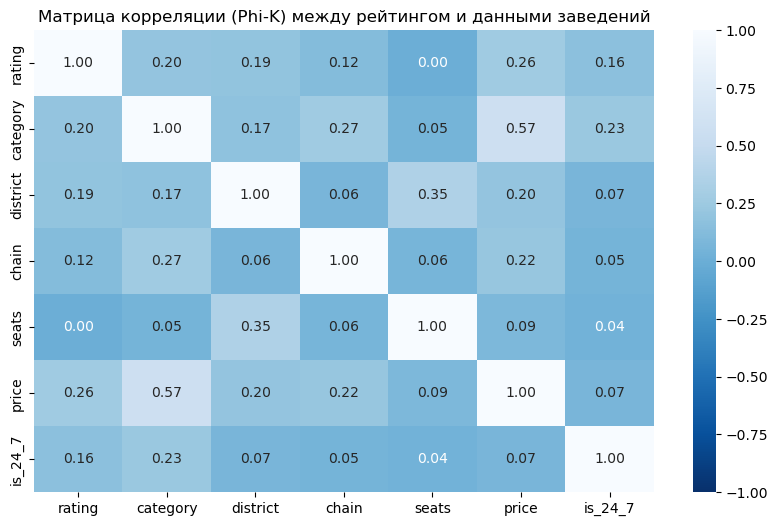

In [64]:
# Сделаем тепловую карту
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues_r', vmin=-1, vmax=1, fmt=".2f")
plt.title('Матрица корреляции (Phi-K) между рейтингом и данными заведений')
plt.show()

In [65]:
# Найдем самую сильную корреляцию с рейтингом (исключая корреляцию с самим собой)
corr_rating = corr_matrix['rating'].drop('rating')
corr_strong = corr_rating.abs().idxmax()
corr_strong_rating = corr_rating[corr_strong]

print(f'Самая сильная корреляция с рейтингом: {corr_strong} ({corr_strong_rating:.2f})')

Самая сильная корреляция с рейтингом: price (0.26)


In [66]:
# Проверим, сгруппировав по ценам
price_rating = merged_df.groupby('price')['rating'].mean().round(2).sort_values(ascending=False)

print('Средний рейтинг по прайсу:')
print(price_rating)

Средний рейтинг по прайсу:
price
высокие          4.44
выше среднего    4.39
средние          4.30
низкие           4.17
Name: rating, dtype: float32


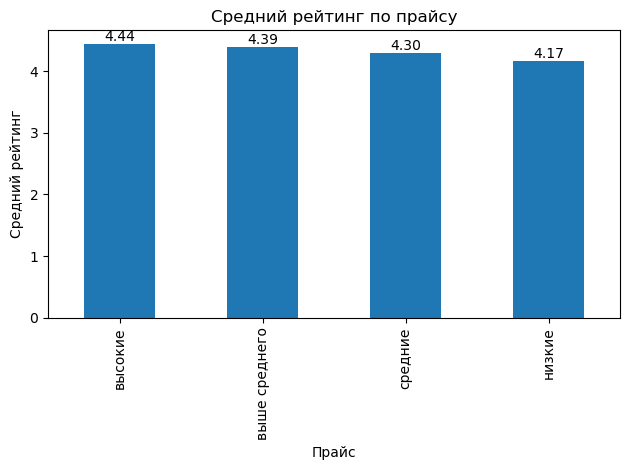

In [67]:
# Строим столбчатую диаграмму
price_rating.plot(kind='bar')

plt.title('Средний рейтинг по прайсу')
plt.xlabel('Прайс')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=90)

# Добавим подписи на столбцы
for i, v in enumerate(price_rating):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Категории прайса имеют положительную корреляцию с рейтингом заведений. Чем выше прайс, тем выше рейтинг.

### Задача 7

ТОП-15 популярных сетей Москвы по количеству заведений этой сети в регионе. Средний рейтинг и категория заведения.

In [68]:
# Сгруппируем и отсортируем сетевые заведения
top_chain = merged_df[merged_df['chain'] == 1].groupby(['name', 'category']).agg(
            count_venue=('name', 'count'),  # Количество заведений сети
            avg_rating=('rating', 'mean')    # Средний рейтинг
).sort_values('count_venue', ascending=False).head(15)
top_chain

,,count_venue,avg_rating
name,category,,
Шоколадница,кофейня,119,4.178151
Домино'с пицца,пиццерия,76,4.169737
Додо пицца,пиццерия,74,4.286487
One price coffee,кофейня,71,4.064789
Яндекс лавка,ресторан,69,3.872464
Cofix,кофейня,65,4.075385
Prime,ресторан,49,4.114285
Кофепорт,кофейня,42,4.147619
Кулинарная лавка братьев караваевых,кафе,39,4.394872


Исключаем из выборки Чайхана.

In [69]:
# Сгруппируем и отсортируем сетевые заведения
top_chain_without_chaikhana = merged_df[(merged_df['chain'] == 1) & (merged_df['name'] != 'Чайхана')].groupby(['name', 'category']).agg(
            count_venue_without_chaikhana=('name', 'count'),  # Количество заведений сети
            avg_rating_without_chaikhana=('rating', 'mean')    # Средний рейтинг
).sort_values('count_venue_without_chaikhana', ascending=False).head(15)
top_chain_without_chaikhana

,,count_venue_without_chaikhana,avg_rating_without_chaikhana
name,category,,
Шоколадница,кофейня,119,4.178151
Домино'с пицца,пиццерия,76,4.169737
Додо пицца,пиццерия,74,4.286487
One price coffee,кофейня,71,4.064789
Яндекс лавка,ресторан,69,3.872464
Cofix,кофейня,65,4.075385
Prime,ресторан,49,4.114285
Кофепорт,кофейня,42,4.147619
Кулинарная лавка братьев караваевых,кафе,39,4.394872


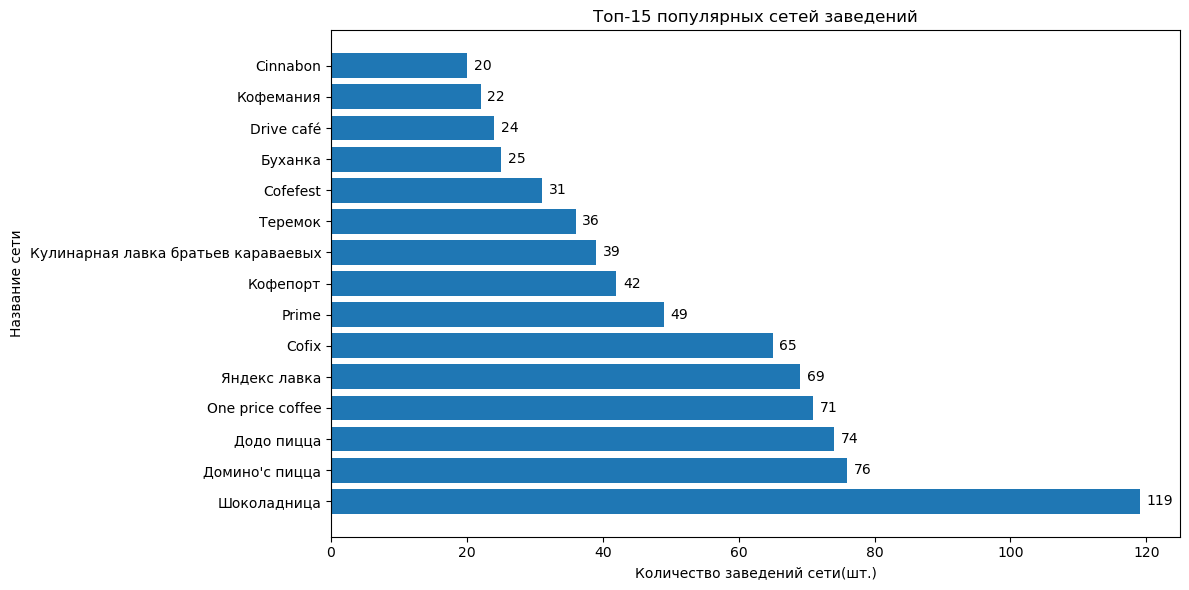

In [70]:
# Сбросим индексы
top_chain_without_chaikhana = top_chain_without_chaikhana.reset_index()

# Строит диаграмму по количеству
plt.figure(figsize=(12, 6))
plt.barh(top_chain_without_chaikhana['name'], top_chain_without_chaikhana['count_venue_without_chaikhana'])

plt.xlabel('Количество заведений сети(шт.)')
plt.ylabel('Название сети')
plt.title('Топ-15 популярных сетей заведений')

# Добавляем цифры на столбцы
for i, v in enumerate(top_chain_without_chaikhana['count_venue_without_chaikhana']):
    plt.text(v+1, i, str(v), va='center')

plt.tight_layout()
plt.show()

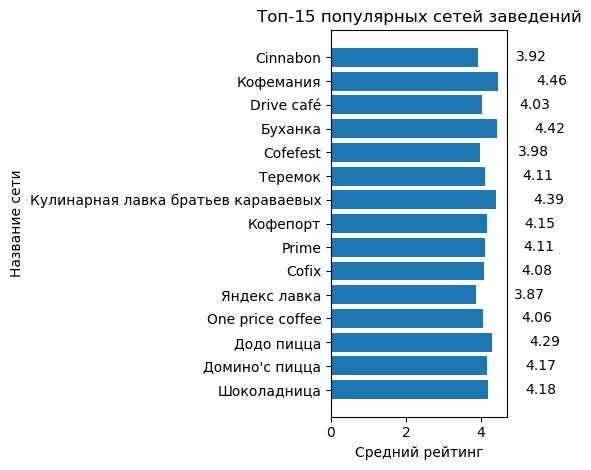

In [71]:
# Строит диаграмму по рейтингу
plt.barh(top_chain_without_chaikhana['name'], top_chain_without_chaikhana['avg_rating_without_chaikhana'])

plt.xlabel('Средний рейтинг')
plt.ylabel('Название сети')
plt.title('Топ-15 популярных сетей заведений')

# Добавляем цифры на столбцы
for i, v in enumerate(top_chain_without_chaikhana['avg_rating_without_chaikhana']):
    plt.text(v+1, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

In [72]:
# Выведем количество по категориям в ТОП-15
top_chain_without_chaikhana['category'].value_counts()

category
кофейня     7
ресторан    3
пиццерия    2
кафе        2
булочная    1
Name: count, dtype: int64

**Итого:**
- по количеству точек сетевых заведений первых три места в ТОП-15 занимают:
  - Шоколадница (119 шт.);
  - Домино'c пицца(76 шт.);
  - Додо пицца(74 шт.);
- средний рейтинг сетей ТОП-15 находится в диапозоне 3.87-4.46;
- по категориям в лидерах кофейни.

### Задача 8

Вариации среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Анализ цены в Центральном административном округе и других. 

In [73]:
# Выведем повторно и отдельно статистические показатели столбца `middle_avg_bill`
merged_df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053650
std       1009.734436
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

В столбце `middle_avg_bill` среднее значение(958) и медиана(750) тоже сильно отличаются, высокое стандартное отклонение - 1009. Высокое максимальное значение(35 000) и минимальное значение(0).

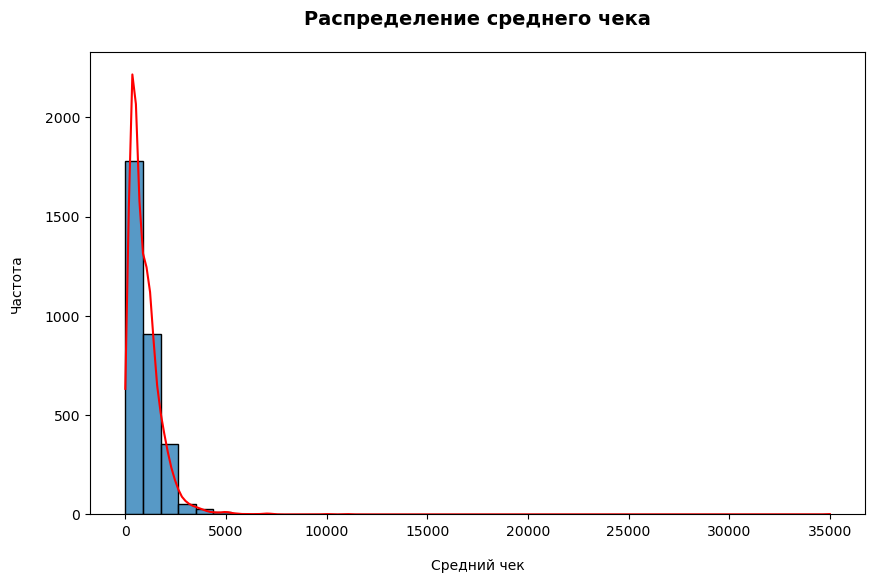

In [74]:
# Строим гистограмму, чтобы увидеть распределение рейтингов заведений
plt.figure(figsize=(10, 6))
hist_rating = sns.histplot(
    merged_df['middle_avg_bill'],
    bins=40,
    kde=True,
    alpha=0.75,
    edgecolor='black')


plt.ylabel('Частота', labelpad=15)
plt.title('Распределение среднего чека', 
        fontsize=14,  
        fontweight='bold',
        pad=20)
hist_rating.lines[0].set_color('red')
plt.xlabel('Средний чек', labelpad=15)
 
plt.show()

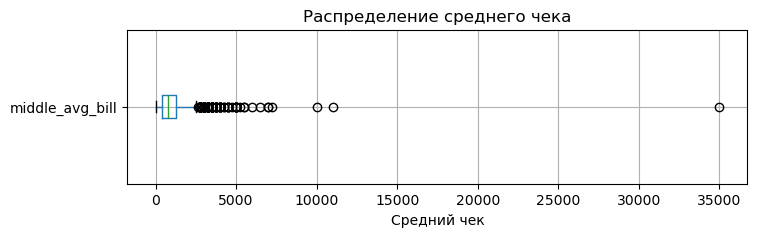

In [75]:
# Создаём ящик с усами для среднего чека
plt.figure(figsize=(8, 2))
merged_df.boxplot(column='middle_avg_bill', vert=False)

plt.title('Распределение среднего чека')
plt.xlabel('Средний чек')

plt.show()

Большинство сумм среднего чека находятся в диапозоне 375-1250. Есть крупные заказы, их немного, но они искажают значения.

In [76]:
# Выведем статистические данные по среднему чеку заведения для каждого района
merged_df.groupby('district').agg(count=('id', 'count'),
min_distr_bill=('middle_avg_bill', 'min'),
max_distr_bill=('middle_avg_bill', 'max'),
median_distr_bill=('middle_avg_bill', 'median')).reset_index()


,district,count,min_distr_bill,max_distr_bill,median_distr_bill
0,Восточный административный округ,798,50.0,10000.0,575.0
1,Западный административный округ,850,50.0,5250.0,1000.0
2,Северный административный округ,898,130.0,11000.0,650.0
3,Северо-Восточный административный округ,890,50.0,4500.0,500.0
4,Северо-Западный административный округ,409,120.0,2900.0,700.0
5,Центральный административный округ,2242,0.0,7250.0,1000.0
6,Юго-Восточный административный округ,714,30.0,3750.0,450.0
7,Юго-Западный административный округ,709,100.0,2750.0,600.0
8,Южный административный округ,892,100.0,35000.0,500.0


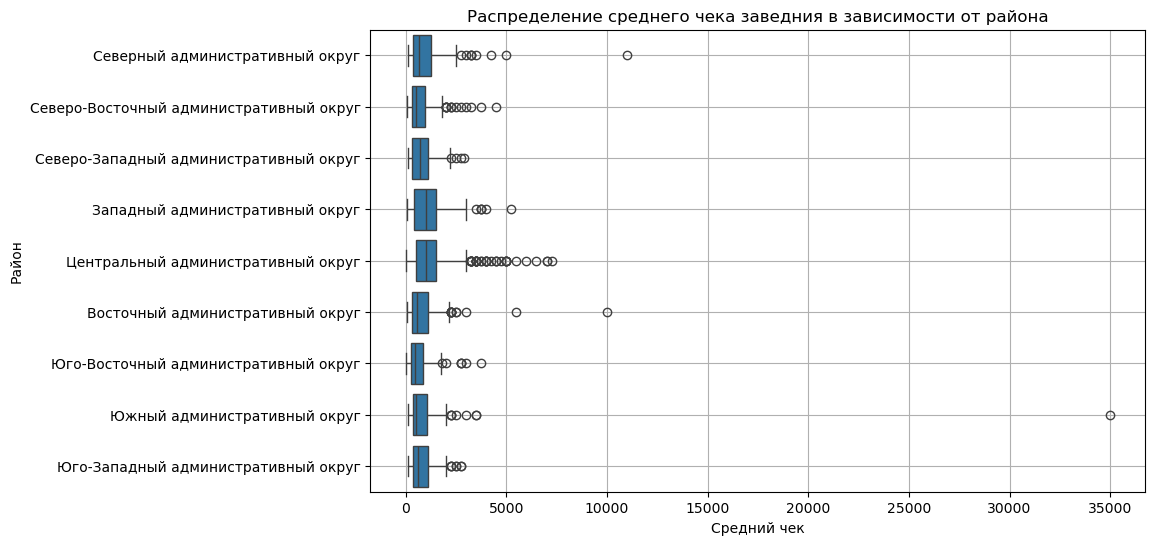

In [77]:
# Посмотрим на ящиках с усами
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, y='district', x='middle_avg_bill')

plt.title('Распределение среднего чека заведния в зависимости от района')
plt.xlabel('Средний чек')
plt.ylabel('Район')

plt.grid()
plt.show()

Для удобства следует удалить выбросы и переделать boxplot.

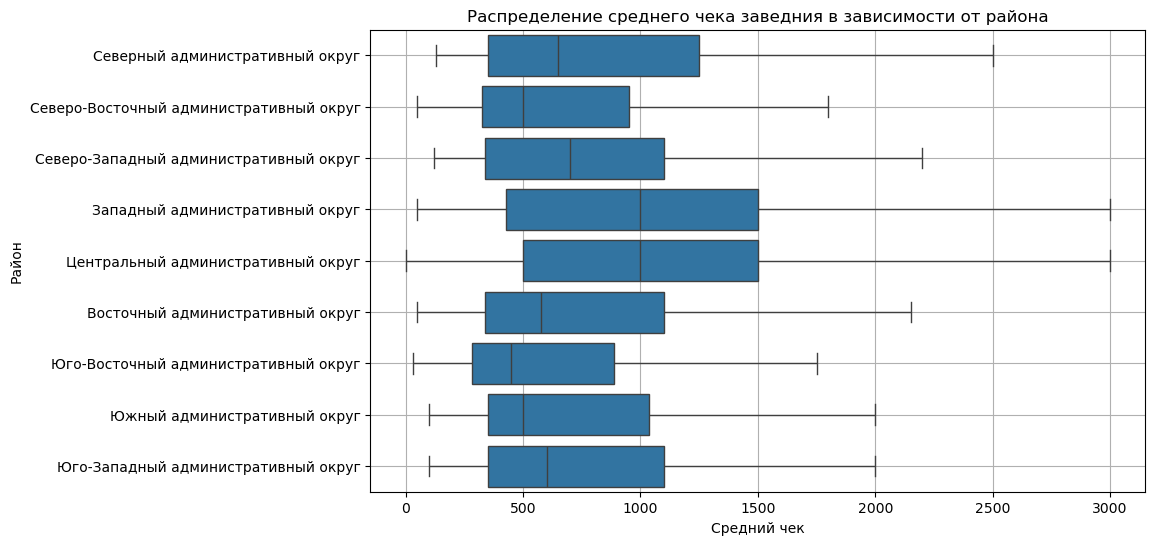

In [78]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=merged_df, y='district', x='middle_avg_bill', showfliers=False)

plt.title('Распределение среднего чека заведния в зависимости от района')
plt.xlabel('Средний чек')
plt.ylabel('Район')

plt.grid()
plt.show()

**Итого:**
- Центральный и Западный округа являются лидерами по среднему чеку - 1000 рублей.
- Юго-Восточный и Северо-Восточный имеют наименьшие средние чеки - 450 и 500 рублей соответственно.
- Южный округ имеет тоже наименьший средний чек в 500 рублей, но тут наблюдаются и аномально высокие значения.

Можно заметить, что по мере удаления от центра сумма среднего чека уменьшается.

### Промежуточный вывод

**Категории заведений**

Самые распространённые категории в Москве - это кафе, рестораны и кофейни. Булочных меньше всего.

**Распределение по районам**

Больше всего заведений сконцентрировано в Центральном административном округе(ЦАО) - 2242 шт., 26.68% от общего в Москве.
Меньше всего в Северо-Западном административном округе(СЗАО) - 409 шт..
В остальных районах варьируется в диапозоне 709-898 шт..


**Сетевые/несетевые заведения**

В Москве из 8402 заведений общественного питания несетевых - 5198 шт. или 61.87%, сетевых - 3204 шт. или 38.13%, следовательно несетевые заведения значительно преобладают.

**Количество посадочных мест**

Больше всего посадочных мест - в ресторанах, самое маленькое - для булочных.

**Рейтинг заведений**

Средний рейтинг заведений достаточно высок - 4.23 из 5 возможных.
Чем выше ценовая категория, тем выше рейтинг.

**ТОП-15 сетей по количеству точек Москвы**

В ТОП-3:
- Шоколадница (119 шт.);
- Домино'c пицца(76 шт.);
- Додо пицца(74 шт.);

Cредний рейтинг сетей ТОП-15 находится в диапозоне 3.87-4.46 и по категориям в лидерах кофейни.

**Средний чек по округам**

Чем ближе к центру, тем дороже(краткость).

## 4. Итоговый вывод и рекомендации

В ходе исследования был проведен комплексный анализ рынка общественного питания Москвы на основе данных Яндекс Карт и Яндекс Бизнеса (лето 2022 года).

Во время анализа были проведены следуюшие шаги:

- загрузка и предобработка данных (оптимизация типов, обработка пропусков, удаление дубликатов);
- исследование распределения заведений по категориям, районам, сетевое/несетевое;
- работа с посадочными местами, рейтингами и ценовыми категориями(прайсом);
- изучение корреляций между рейтингом и другими данными;
- ТОП-15 сетевых заведений по количеству точек и их анализ;
- разбор среднего чека в зависимости от района Москвы.

**Отметки на основе проведённой работы**

Если брать на основе среднего чека(высокий), то стоит обратить внимание на Центральный и Западный округи. Здесь можно выделить такие типы заведений, как сетевые кофейни, сетевые пиццерии и более высокий уровень - рестораны.

Не думаю, что перезаполненность сетевыми точками в данных округах сыграют в худшую сторону, так как сетевые заведения - это проверенные модели работы и достаточно высокий рейтинг.

По категории ресторанов лучше сфокусировать свое внимание на сервисе, комфорте и заботе клиента, при разработке меню не стоит опасаться установления цен выше среднерыночных.

Если рассмотреть менее насыщенные районы, то ставку стоит сделать на булочные и пекарни и располагать их в проходимых точках районов, т.е. рекомендуется провести дополнительный анализ спроса и арендных ставок в выбранных районах.
